# SVM Process

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("alarmbell mfcc 65 features.txt", sep="\s+", header=None)
print(df)

      0         1        2        3        4        5        6        7   \
0      1  84.52785 -5.24913  0.78909  0.65499  0.74242  0.01507  0.11068   
1      2  84.76906 -5.62529 -1.33732  0.62160  0.62980  0.14054  0.22197   
2      3  84.95055 -5.35771 -1.43229  0.66601  0.83747  0.30444  0.53497   
3      4  84.60520 -5.63012 -1.20258  0.46717  0.29365  0.54449  0.37009   
4      5  84.48011 -5.34170  0.93660  0.78124  0.46342  0.36378  0.49650   
...   ..       ...      ...      ...      ...      ...      ...      ...   
1255   1  85.35689 -4.41083  0.15084  0.38914  0.03823  0.23895  0.34008   
1256   2  84.96530 -3.96984  0.67802  0.21291  0.04572  0.45787  0.91793   
1257   3  84.39422 -4.91930 -1.14873  0.40425  0.00840  0.11464  0.17853   
1258   4  84.07147 -5.30344 -1.44307  0.77442  0.45831  0.22321  0.08537   
1259   5  84.47391 -4.71889  0.88140  0.66086  0.58869  0.21063  0.14306   

           8        9        10       11       12       13  
0     0.23735  0.05288  0.

In [3]:
ndf= df.drop(df.columns[0],axis=1)

In [4]:
ndf.shape

(1260, 13)

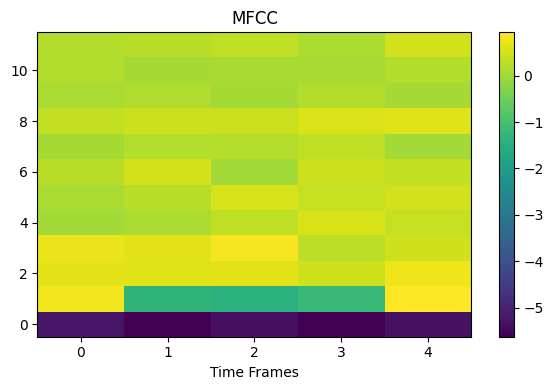

In [5]:
vis_df = ndf[:5]
arr = np.array(vis_df)


#mfcc_plot = vis_df.T  # Now (13,5)

#scaler = StandardScaler()
#norm_arr = scaler.fit_transform(arr)  # Automatically handles shape

norm_arr = arr[:, 1:]


plt.figure(figsize=(6, 4))
plt.imshow(norm_arr.T, aspect='auto', origin='lower')
plt.colorbar()
plt.xlabel('Time Frames')
#plt.ylabel('MFCC Coefficients')
#plt.yticks(range(12), [f'C{i+1}' for i in range(12)])
plt.title('MFCC')
plt.tight_layout()
plt.show()


In [6]:
rows_per_block = 5

arr = ndf.to_numpy()

n_rows, n_cols = ndf.shape   # n_cols = 13

df_wide = arr.reshape(-1, rows_per_block, n_cols) \
             .reshape(-1, rows_per_block * n_cols)

df_wide = pd.DataFrame(df_wide)
print(df_wide)

           0        1        2        3        4        5        6        7   \
0    84.52785 -5.24913  0.78909  0.65499  0.74242  0.01507  0.11068  0.23735   
1    85.16338 -4.95625 -1.03039  0.24969  0.24572  0.17705  0.44220  0.46207   
2    83.80902 -5.03937  0.89918  0.15514  0.09652  0.15712  0.03675  0.24143   
3    84.30218 -4.94702  0.90720  0.18495  0.30842  0.21782  0.32925  0.22828   
4    84.79015 -5.13974  0.97950  0.27697  0.06370  0.30971  0.18635  0.06974   
..        ...      ...      ...      ...      ...      ...      ...      ...   
247  84.22503 -4.83435 -1.03148  0.56571  0.39001  0.45602  0.01769  0.21869   
248  84.93987 -4.81075 -1.11470  0.59309  0.41919  0.33020  0.14689  0.02502   
249  84.21842 -4.94519 -1.10719  0.73474  0.14579  0.08666  0.15579  0.16277   
250  84.48116 -5.34796  0.94045  0.35344  0.36542  0.23122  0.28501  0.05446   
251  85.35689 -4.41083  0.15084  0.38914  0.03823  0.23895  0.34008  0.18241   

          8        9   ...       55    

In [7]:
df_wide.head(2)

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,64
0,84.52785,-5.24913,0.78909,0.65499,0.74242,0.01507,0.11068,0.23735,0.05288,0.33883,...,0.78124,0.46342,0.36378,0.4965,0.32296,0.02318,0.61901,0.06402,0.18922,0.49618
1,85.16338,-4.95625,-1.03039,0.24969,0.24572,0.17705,0.44220,0.46207,0.09152,0.23374,...,0.95892,0.14819,0.06747,0.2434,0.05599,0.14995,0.43669,0.07914,0.08542,0.10589


In [8]:
df2 = pd.read_csv("noise mfcc 65 features.txt", sep="\s+", header=None)
print(df2)

      0         1        2        3        4        5        6        7   \
0      1  84.17995 -5.21321  0.84406  0.18390  0.26192  0.26212  0.14402   
1      2  84.31833 -5.16478 -1.35990 -1.03171  0.53450  0.23950  0.63252   
2      3  84.24648 -4.85578 -1.18518  0.68580  0.31130  0.10761  0.16302   
3      4  84.17786 -5.23928 -1.37379  0.85376  0.51200  0.72918  0.20817   
4      5  84.00627 -5.37259 -1.26423  0.80729  0.14887  0.07548  0.07350   
...   ..       ...      ...      ...      ...      ...      ...      ...   
1265   1  86.49020 -5.09387 -1.92715  0.82455 -1.25389  0.01026  0.31988   
1266   2  85.59901 -4.83828 -1.71895 -1.34906  0.76320  0.42725  0.38307   
1267   3  87.61242 -5.09266 -2.17824  0.92255  0.63904  0.45862  0.87344   
1268   4  83.80038 -5.54611 -1.62810  0.94676  0.51138  0.84667  0.29848   
1269   5  84.66731 -5.46159 -1.52844  0.74273  0.22663  0.12627  0.13805   

           8        9        10       11       12       13  
0     0.14676  0.07479  0.

In [9]:
ndf2= df2.drop(df2.columns[0],axis=1)

In [10]:
rows_per_block = 5

arr = ndf2.to_numpy()

n_rows, n_cols = ndf2.shape   # n_cols = 13

df_wide2 = arr.reshape(-1, rows_per_block, n_cols) \
             .reshape(-1, rows_per_block * n_cols)

df_wide2 = pd.DataFrame(df_wide2)
print(df_wide2)

           0        1        2        3        4        5        6        7   \
0    84.17995 -5.21321  0.84406  0.18390  0.26192  0.26212  0.14402  0.14676   
1    83.73060 -5.30891 -1.48755  0.65931  0.48647  0.07977  0.04986  0.08200   
2    83.92593 -4.96255 -1.06874  0.65109  0.03590  0.06930  0.30862  0.46074   
3    83.84221 -4.95895  0.88096  0.66232 -1.11968  0.57139  0.42873  0.62351   
4    83.01526 -5.18006 -1.20164  0.54665  0.49000  0.28919  0.25911  0.13213   
..        ...      ...      ...      ...      ...      ...      ...      ...   
249  86.93074 -5.15342 -1.98684  0.64866 -1.37866  0.29309  0.00495  0.55386   
250  84.98930 -4.70599 -1.42946  0.83205  0.46047  0.47967  0.14568  0.30851   
251  88.03902 -4.93917 -1.66490  1.63721  0.54060  0.79750  0.19060  0.03199   
252  86.48985 -4.74483 -2.33373  0.62482  0.11633  0.63223  0.67648  0.21210   
253  86.49020 -5.09387 -1.92715  0.82455 -1.25389  0.01026  0.31988  0.38107   

          8        9   ...       55    

In [11]:
df_wide2.head(2)

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,64
0,84.17995,-5.21321,0.84406,0.18390,0.26192,0.26212,0.14402,0.14676,0.07479,0.10995,...,0.80729,0.14887,0.07548,0.07350,0.51498,0.29675,0.00209,0.06162,0.14988,0.22753
1,83.73060,-5.30891,-1.48755,0.65931,0.48647,0.07977,0.04986,0.08200,0.13579,0.07637,...,0.73493,0.42130,0.43110,0.31797,0.33741,0.16132,0.33077,0.07721,0.02223,0.15210


In [12]:
df_wide['label'] = 1   # class 1
df_wide2['label'] = 0   # class 0

In [13]:
df_all = pd.concat([df_wide, df_wide2], axis=0, ignore_index=True)

In [14]:
X = df_all.drop(columns=['label']).values
y = df_all['label'].values

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [16]:
from sklearn.svm import SVC

clf = SVC(kernel='rbf',C=10, gamma ='auto')
clf.fit(X_train, y_train)


SVC(C=10, gamma='auto')

In [17]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.8823529411764706

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.96      0.89        51
           1       0.95      0.80      0.87        51

    accuracy                           0.88       102
   macro avg       0.89      0.88      0.88       102
weighted avg       0.89      0.88      0.88       102


Confusion Matrix:
 [[49  2]
 [10 41]]


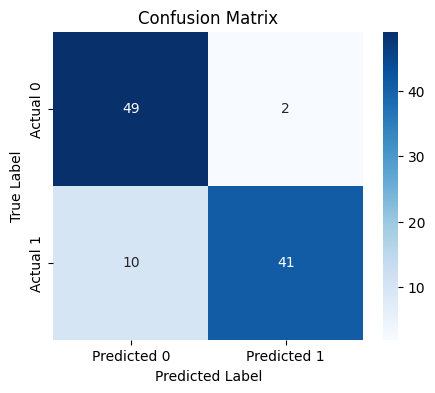

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm = np.array(  [[49 ,  2],
 [ 10 , 41]])

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted 0", "Predicted 1"],
            yticklabels=["Actual 0", "Actual 1"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


In [19]:
print(clf.get_params())

{'C': 10, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'auto', 'kernel': 'rbf', 'max_iter': -1, 'probability': False, 'random_state': None, 'shrinking': True, 'tol': 0.001, 'verbose': False}


In [20]:
supportShape = clf.support_vectors_.shape

nbSupportVectors = supportShape[0]
vectorDimensions = supportShape[1]

print("nbSupportVectors = %d" % nbSupportVectors)
print("vectorDimensions = %d" % vectorDimensions)
print("degree = %d" % clf.degree)
print("coef0 = %f" % clf.coef0)
print("gamma = %f" % clf._gamma)

print("intercept = %f" % clf.intercept_)

nbSupportVectors = 124
vectorDimensions = 65
degree = 3
coef0 = 0.000000
gamma = 0.015385
intercept = -1.078892


C:\Users\lenovo\AppData\Local\Temp\ipykernel_13092\1122964275.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("intercept = %f" % clf.intercept_)


In [21]:
dualCoefs = clf.dual_coef_
dualCoefs = dualCoefs.reshape(nbSupportVectors)
supportVectors = clf.support_vectors_
supportVectors = supportVectors.reshape(nbSupportVectors * vectorDimensions)

print("Dual Coefs")
print(dualCoefs.shape)

print("Support Vectors")
print(supportVectors.shape)

Dual Coefs
(124,)
Support Vectors
(8060,)


In [23]:
print("dualCoefs = {" + ", ".join(map(str, dualCoefs)) + "};")
print("supportVectors = {" + ", ".join(map(str, supportVectors)) + "};")

dualCoefs = {-10.0, -1.7467137003502515, -0.7511722771685219, -10.0, -0.9763708693118949, -4.422362521328419, -1.6628844671830192, -3.8055407082726034, -10.0, -3.5592538928017468, -10.0, -10.0, -0.5391844921716764, -9.969516215456663, -10.0, -10.0, -10.0, -10.0, -3.079623424581665, -1.35290710853534, -7.257041506292482, -1.7787025126415172, -1.173993500005754, -0.31872615586355957, -10.0, -6.817246138698866, -10.0, -7.5427072181179895, -1.496166962704688, -1.7573134207775467, -0.15826326000984214, -10.0, -1.1523943268286954, -0.8595156281702122, -2.3008221489361103, -1.9029513063648829, -10.0, -10.0, -4.91340927858704, -10.0, -1.1144641207620036, -10.0, -4.5125098615417825, -2.873075571713685, -10.0, -10.0, -0.6662317497479193, -10.0, -0.18857281502867226, -6.46285391322907, -10.0, -4.803005761477532, -9.392006212860094, -10.0, -9.452830531375612, -2.015157087729144, -10.0, -5.603931983194541, -10.0, -3.9947266285748713, -6.209729412360871, -5.320090052551711, -10.0, -8.5243072249388, 

### Copy the above parameters and paste them in the src file

# Testing  

In [68]:
param_grid = {
    'C': [0.1,1,10,50,100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.0001],
    'coef0': [0, 1, 5]
    #'degree':[2,3,4]
}

# Run separate GridSearchCV for each kernel
kernels = ['sigmoid']
results = {}

for kernel in kernels:
    svc = SVC(kernel=kernel)
    grid_search = GridSearchCV(svc, param_grid, cv=5, scoring='accuracy')
    grid_search.fit(X_train, y_train)
    results[kernel] = grid_search.best_params_
    print(f"{kernel}: {grid_search.best_score_:.3f} - {grid_search.best_params_}")


sigmoid: 0.701 - {'C': 50, 'coef0': 0, 'gamma': 'scale'}


In [69]:
clf = SVC(kernel='sigmoid',C=50, gamma='scale',coef0=0)

clf.fit(X_train, y_train)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.6941580756013745

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.63      0.70       162
           1       0.62      0.78      0.69       129

    accuracy                           0.69       291
   macro avg       0.70      0.70      0.69       291
weighted avg       0.71      0.69      0.69       291


Confusion Matrix:
 [[102  60]
 [ 29 100]]
